# Griffiths Ch. 5 — Magnetostatics

Steady currents and the fields they make. The magnetic force does no work (it is always
perpendicular to velocity), so it *curves* rather than speeds up — giving **cyclotron motion**. The
sources are currents, the law is **Biot-Savart** (or **Ampere** when there's symmetry), and the two
structural facts are $\nabla\cdot\mathbf B=0$ (no monopoles) and $\nabla\times\mathbf B=\mu_0\mathbf J$.

This chapter is the magnetic mirror of Ch. 2: the on-axis field of a **current loop** is the dual of
the charged **ring**, the vector potential $\mathbf A$ plays the role of $V$, and the whole structure
foreshadows that $\mathbf E$ and $\mathbf B$ are one relativistic object (PS#1). Engine:
`griffiths.magnetostatics`.

In [3]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from IPython.display import display, Math

import griffiths as gr
from griffiths import magnetostatics as mag

sp.init_printing(use_latex="mathjax")
q, m, B, I, R, s, n = sp.symbols("q m B I R s n", positive=True)
vperp, vpar, t = sp.symbols("v_perp v_par t", positive=True)
print("griffiths.magnetostatics loaded; mu_0 symbolic")

griffiths.magnetostatics loaded; mu_0 symbolic


## §1 Magnetic force and cyclotron motion

$\mathbf F=q\,\mathbf v\times\mathbf B$. In a uniform $\mathbf B=B\hat z$ a charge spirals: circular
in the plane, drifting along the field. The angular frequency
$\omega_c=\dfrac{qB}{m}$ is **independent of speed** (isochronism — the principle of the cyclotron),
and the radius is $r=\dfrac{mv_\perp}{qB}$.

In [4]:
display(Math(r"\omega_c = " + sp.latex(mag.cyclotron_frequency(q, m, B))
             + r",\qquad T = " + sp.latex(mag.cyclotron_period(q, m, B))
             + r",\qquad r = " + sp.latex(mag.cyclotron_radius(m, vperp, q, B))))

# verify the helical trajectory solves m a = q v x B
xt, yt, zt = mag.cyclotron_trajectory(q, m, B, vperp, vpar, t)
rvec = sp.Matrix([xt, yt, zt])
residual = sp.simplify(m * rvec.diff(t, 2) - q * rvec.diff(t).cross(sp.Matrix([0, 0, B])))
print("trajectory solves m a = q v x B:", residual == sp.zeros(3, 1))

<IPython.core.display.Math object>

trajectory solves m a = q v x B: True


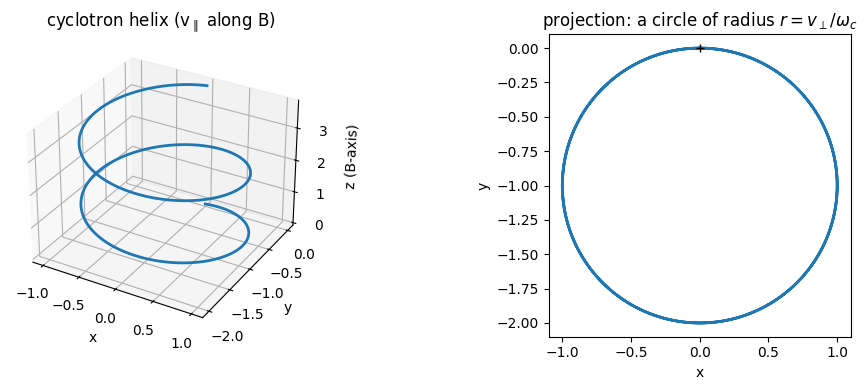

<IPython.core.display.Math object>

In [5]:
# numeric helix (electron-like): q=m=B=1, vperp=1, vpar=0.3
import numpy as np
ts = np.linspace(0, 4*np.pi, 600)
w = 1.0; vp, vz = 1.0, 0.3
X = (vp/w)*np.sin(w*ts); Y = (vp/w)*(np.cos(w*ts)-1); Z = vz*ts

fig = plt.figure(figsize=(11, 4))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.plot(X, Y, Z, lw=2); ax1.set_title("cyclotron helix (v$_\\parallel$ along B)")
ax1.set_xlabel("x"); ax1.set_ylabel("y"); ax1.set_zlabel("z (B-axis)")
ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(X, Y, lw=2); ax2.plot(0, 0, "k+"); ax2.set_aspect("equal")
ax2.set_title("projection: a circle of radius $r=v_\\perp/\\omega_c$"); ax2.set_xlabel("x"); ax2.set_ylabel("y")
plt.tight_layout(); plt.show()

# velocity selector: E x B drift is charge-independent
E0 = sp.Symbol("E_0", positive=True)
vd = mag.ExB_drift([E0, 0, 0], [0, 0, B])
display(Math(r"\text{crossed fields: } \mathbf v_{\rm drift} = \frac{\mathbf E\times\mathbf B}{B^2} = "
             + sp.latex(vd.T) + r"\quad(\text{independent of }q,m\text{: a velocity selector})"))

## §2 Biot-Savart: the straight wire

$\mathbf B=\dfrac{\mu_0}{4\pi}\displaystyle\int\dfrac{I\,d\boldsymbol\ell\times\hat{\mathscr r}}{\mathscr r^2}$.
For an infinite straight wire it gives the textbook $B=\dfrac{\mu_0 I}{2\pi s}$, circulating around
the wire — falling as $1/s$, the magnetic cousin of the line charge's $1/s$ field.

In [6]:
display(Math(r"B(s) = " + sp.latex(mag.wire_field(I, s)) + r" = \frac{\mu_0 I}{2\pi s}"))
display(Math(r"\text{Ampere check: } 2\pi s\,B = \mu_0 I \Rightarrow B = "
             + sp.latex(mag.ampere_enclosed_wire(I, s))))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## §3 The current loop — dual of the charged ring

On the axis of a circular loop (radius $R$, current $I$):

$$B_z=\frac{\mu_0 I R^2}{2\,(R^2+z^2)^{3/2}}.$$

Compare the charged ring's $E_z=\dfrac{1}{4\pi\epsilon_0}\dfrac{\lambda(2\pi R)z}{(R^2+z^2)^{3/2}}$
(Griffiths 2.5): same $(R^2+z^2)^{3/2}$ denominator, but the loop peaks at the **center** while the
ring's field **vanishes** there — the duality with a twist.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

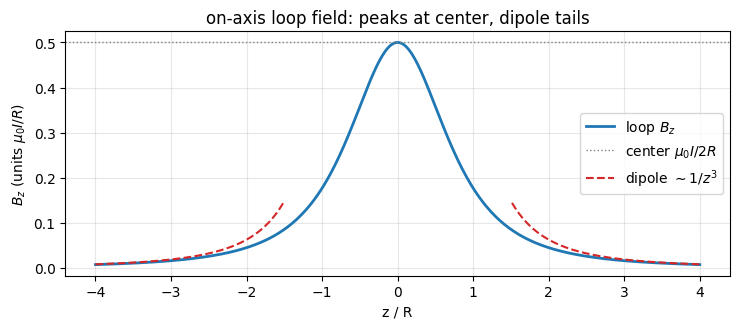

In [7]:
Bz = mag.loop_field_axis(I, R, gr.z)
display(Math(r"B_z(z) = " + sp.latex(Bz)))
display(Math(r"\text{center } z=0:\ " + sp.latex(sp.simplify(Bz.subs(gr.z, 0)))
             + r" = \frac{\mu_0 I}{2R};\quad z\gg R:\ \to \frac{\mu_0 I R^2}{2 z^3}"
             r"\ (\text{dipole, } m=" + sp.latex(mag.magnetic_dipole_moment(I, R)) + r")"))

zz = np.linspace(-4, 4, 400)
Bzf = sp.lambdify(gr.z, Bz.subs({mag.mu0: 1, I: 1, R: 1}), "numpy")
plt.figure(figsize=(7.5, 3.4))
plt.plot(zz, Bzf(zz), lw=2, label="loop $B_z$")
plt.axhline(0.5, color="gray", ls=":", lw=1, label="center $\\mu_0 I/2R$")
plt.plot(zz, np.where(np.abs(zz) > 1.5, 1/(2*np.abs(zz)**3), np.nan), "C3--", label="dipole $\\sim 1/z^3$")
plt.xlabel("z / R"); plt.ylabel("$B_z$ (units $\\mu_0 I/R$)"); plt.legend()
plt.title("on-axis loop field: peaks at center, dipole tails"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## §4 Ampere's law: the solenoid

Where symmetry allows, $\oint\mathbf B\cdot d\boldsymbol\ell=\mu_0 I_{\rm enc}$ beats Biot-Savart.
A long solenoid ($n$ turns per length) has a **uniform** interior field and essentially zero outside:

$$B=\mu_0 n I.$$

In [8]:
display(Math(r"B_{\rm inside} = " + sp.latex(mag.solenoid_field(n, I))
             + r",\qquad B_{\rm outside} = 0"))
print("uniform interior field -> the magnetic analog of a parallel-plate capacitor's uniform E.")

<IPython.core.display.Math object>

uniform interior field -> the magnetic analog of a parallel-plate capacitor's uniform E.


## §5 The vector potential and the two laws

$\mathbf B=\nabla\times\mathbf A$ guarantees $\nabla\cdot\mathbf B=0$ identically — there are **no
magnetic monopoles**. In the Coulomb gauge $\nabla\cdot\mathbf A=0$, Ampere becomes
$\nabla^2\mathbf A=-\mu_0\mathbf J$ — three copies of Poisson's equation, one per component (the same
solver as electrostatics). A current loop's exterior field is a pure **magnetic dipole**.

<IPython.core.display.Math object>

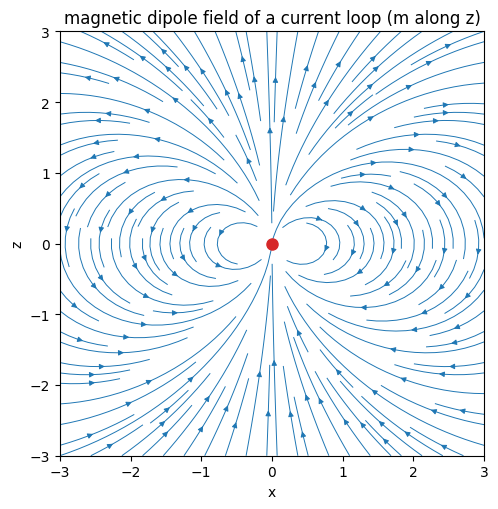

In [9]:
# div(curl A) = 0 for any A
x, y, z = gr.x, gr.y, gr.z
A = sp.Matrix([-y*sp.Function('f')(x, y, z), x*sp.Function('f')(x, y, z), 0])
Bf = mag.B_from_vector_potential(A)
ok, dB = mag.is_divergence_free(Bf)
display(Math(r"\nabla\cdot(\nabla\times\mathbf A) = " + sp.latex(dB) + r"\quad\Rightarrow\ \text{no monopoles}"))

# magnetic dipole field lines (loop seen from afar), dipole along z in the x-z plane
gx = np.linspace(-3, 3, 240); gz = np.linspace(-3, 3, 240)
Xg, Zg = np.meshgrid(gx, gz)
r2 = Xg**2 + Zg**2 + 1e-9
Bx = 3*Xg*Zg / r2**2.5
Bz = (2*Zg**2 - Xg**2) / r2**2.5
plt.figure(figsize=(5.6, 5.2))
plt.streamplot(Xg, Zg, Bx, Bz, density=1.4, color="C0", linewidth=0.7, arrowsize=0.8)
plt.plot(0, 0, "C3o", ms=8); plt.gca().set_aspect("equal")
plt.title("magnetic dipole field of a current loop (m along z)")
plt.xlabel("x"); plt.ylabel("z"); plt.tight_layout(); plt.show()

## §6 Where this lands

- **Cyclotron motion runs the instruments.** $\omega_c=qB/m$ is the principle of the cyclotron and
  the **mass spectrometer** (different $m/q$ → different radius), the gyration in **MRI** and plasma
  confinement, and the bending in every particle accelerator. Speed-independence is why a fixed-frequency
  drive keeps kicking the particle in phase.
- **Electric ring $\leftrightarrow$ magnetic loop.** §3 is literally Griffiths 2.5 with $\lambda\to I$,
  $\epsilon_0\to1/\mu_0$ — the same $(R^2+z^2)^{3/2}$ math the repo's ring/loop integrals use.
- **$\mathbf E$ and $\mathbf B$ are one object.** $\nabla\cdot\mathbf B=0$ and $\nabla\times\mathbf B=
  \mu_0\mathbf J$ join the electrostatic pair to make Maxwell's equations; the boost that mixes them is
  the rapidity machinery from `regan_ps1_relativity.ipynb`. A pure $\mathbf B$ in one frame is part
  $\mathbf E$ in another.

Engine added this session: `griffiths/magnetostatics.py` (Lorentz force, cyclotron, Biot-Savart wire
& loop, solenoid, vector potential, div B / curl B), benchmarked in `scripts/smoke_magnetostatics.py`.
The `griffiths` package now spans Griffiths Ch. 1-5.